#Neural Networks
In this notebook, we are going to explore how to implement various neural networks in python.

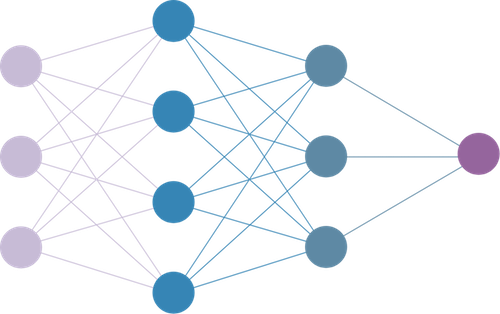



There are many ways to accomplish this objective in python using:

*   Scikit-learn: depending on the network we want to implement, scikit-learn has some simple but useful tools.
*   Keras: Keras provides an easy to use API on top of TensorFlow (among other backends) which could be very helpful
*   TensorFlow: if Keras is not up to the task (e.g. because the dataset is very large), TensorFlow provides both high and low level APIs which could help us perform the task at hand.
*   PyTorch: in contrast to TensorFlow, PyTorch only provides low level APIs and a lot of the stuff has to be taken care of manually, but it might worth it becuase of its speed.


If none of the above approaches work, we have to get our hands dirty and start developing our model from scratch.


In what follows, we are going to very briefly examine the above options.





### Tensorflow
TensorFlow is an open source library, created by Google in 2017. It is developed for dataflow programming to accomplish a range of tasks in machine learning.


*   It is **not** limited to neural networks and can be used for a range of other algorithms too (e.g. KMeans, Random Forests, SVMs, etc.)
*   It is more mature than PyTorch, so the community is larger which means it would be probably easier to debug
*  It provides both high and low level APIs to work with


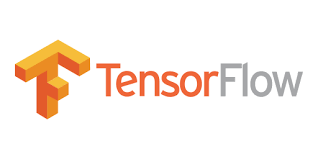

### PyTorch
PyTorch is another open source library, created by Facebook in 2018.

*   It is mainly used for fast tensor computing (similar to Numpy) and developing neural networks
*  It provides only low level APIs to work with
*  Similar to TensorFlow, it has a very high performance, especially during the training phase.

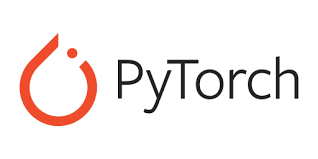



### Keras
Keras provides a high level API, to make working with (deep) neural networks easier.
*   It works with several deep learning backends such as TensorFlow, Theano and CNTK.
*   It is limited to neural networks

Keras is excellent when trying to quickly test models in rather small datasets.

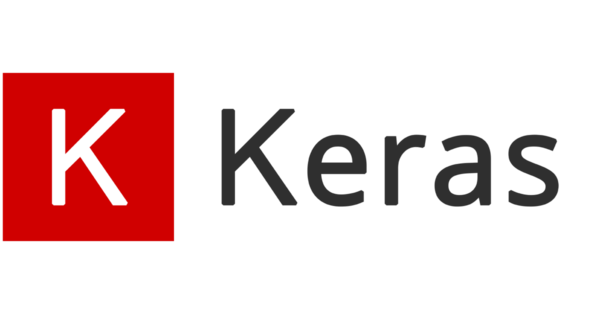

#About the Dataset: Rainfall in Australia
The dataset we work with in this lab session is about predicting the rainfall on a given day in Australia. The data is [hosted on Kaggle](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package), containing 145460 rows and 23 columns.

Our task would be to find features and predict if it will rain "tomorrow" on a given day in a specific city in Australia.

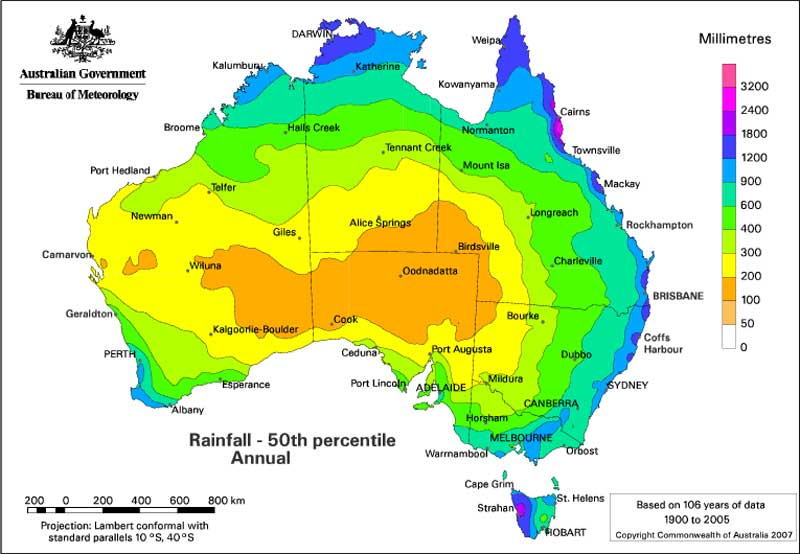

# Installing and Importing Libraries
For the examples we will work on in this notebook, we first need to upgrade the scikit-learn libraries.

Please note that **we will need to restart runtime** after executing the following block.

In [ ]:
# First, let's upgrade scikit-learn package in colab
#!pip uninstall scikit-learn -y
#!pip install -U scikit-learn
import sklearn
#print(sklearn.__version__)

Now let's import the libraries we will need later on.

In [ ]:
import pandas as pd
import io
import os
import numpy as np
import copy
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline
sns.set(color_codes=True)

# Loading the Dataset
Given the size, we load the data directly from Kaggle this time.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"

In [ ]:
! kaggle datasets download -d jsphyg/weather-dataset-rattle-package

100% 3.83M/3.83M [00:00<00:00, 5.76MB/s]
100% 3.83M/3.83M [00:00<00:00, 4.20MB/s]


In [ ]:
!unzip \*.zip && rm *.zip

Archive:  weather-dataset-rattle-package.zip
  inflating: weatherAUS.csv          


Next step would be to load the CSV file into a Pandas dataframe.

In [ ]:
df = pd.read_csv('weatherAUS.csv')
print(df.shape)

(145460, 23)


Now let's take a look at the first few rows of the data:

In [ ]:
df.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


And here's a summary of the dataset as a whole.
It shows us the columns, their datatype, and how many values in that column are null (empty/missing data). Thankfully, we don't have any missing values!

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

# Getting Some Insights from Our Data
It is now time to do some EDA! We just play with different data columns to get more sense about our data.

First, let's check the distribution of palyers age

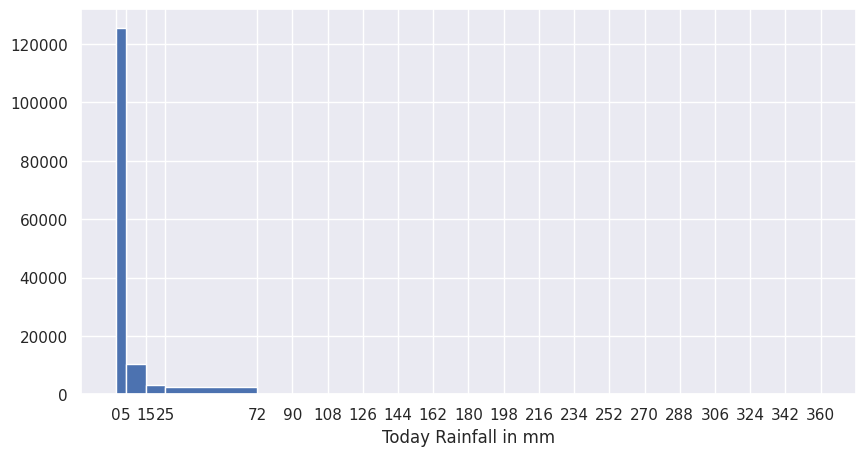

In [ ]:
# Setup bins
no_bins = 20
min_bin_value = int(df['Rainfall'].min())
max_bin_value = int(df['Rainfall'].max())+1
no_data_points = df.shape[0]
predefined_bins = list(range(min_bin_value,max_bin_value,int((max_bin_value-min_bin_value)/no_bins)))
predefined_bins[1] = 5
predefined_bins[2] = 15
predefined_bins[3] = 25

# Create the histogram
df['Rainfall'].hist(bins=predefined_bins,figsize=(10,5))

# Now let's setup the labels, titles and format y axis as percentages
plt.xlabel('Today Rainfall in mm')
plt.xticks(predefined_bins)
plt.show()

Next, let's see the pairplot of some of the columns and how they correlate with the position.

/usr/local/lib/python3.7/dist-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


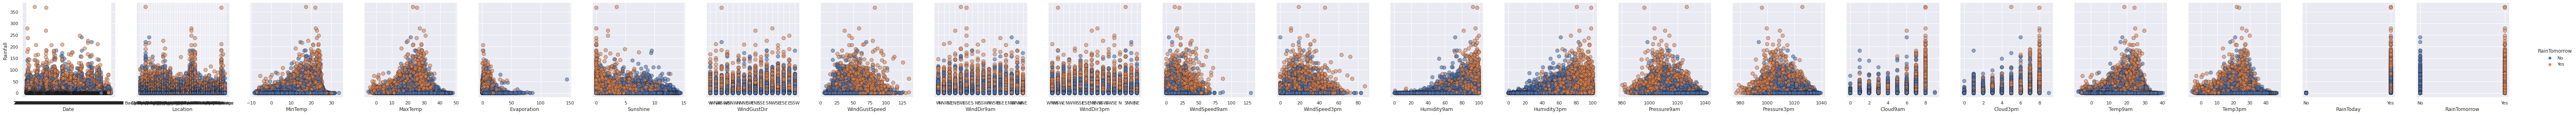

In [ ]:
cols_to_plot = list(df.columns)
cols_to_plot.remove('Rainfall')

sns.pairplot(data=df,
                  y_vars=['Rainfall'],
                  x_vars=cols_to_plot,
                  hue='RainTomorrow',
                  plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
                  size = 4)

# Data Cleaning
From the above overview, we saw some rows with null values. To save time, we simply drop them here.

In [ ]:
null_columns = []
for col_name in list(df.columns):
  no_null_values = sum(df[col_name].isnull())
  if no_null_values:
    print('Number of null values in column %s is %d' %(col_name,no_null_values))
    null_columns.append(col_name)

Number of null values in column MinTemp is 1485
Number of null values in column MaxTemp is 1261
Number of null values in column Rainfall is 3261
Number of null values in column Evaporation is 62790
Number of null values in column Sunshine is 69835
Number of null values in column WindGustDir is 10326
Number of null values in column WindGustSpeed is 10263
Number of null values in column WindDir9am is 10566
Number of null values in column WindDir3pm is 4228
Number of null values in column WindSpeed9am is 1767
Number of null values in column WindSpeed3pm is 3062
Number of null values in column Humidity9am is 2654
Number of null values in column Humidity3pm is 4507
Number of null values in column Pressure9am is 15065
Number of null values in column Pressure3pm is 15028
Number of null values in column Cloud9am is 55888
Number of null values in column Cloud3pm is 59358
Number of null values in column Temp9am is 1767
Number of null values in column Temp3pm is 3609
Number of null values in colu

In order not to lose data, let's fill some of the null columns with the average for that area (a more advanced approach would be to take the date into account as well, i.e. fill in with the average value for that location and in a limited time window):

In [ ]:
null_columns.remove('RainTomorrow')
null_columns.remove('RainToday')

In [ ]:
for col_name in null_columns:
  try:
    df[col_name].fillna(df.groupby('Location')[col_name].transform('mean'),inplace=True)
  except:

    try:
      # Especially with categorical variables
      df[col_name].fillna(df[col_name].mode()[0], inplace=True)
    except:
      pass

for col_name in null_columns:
  # In case there is no value for a particula location, fill it with the overall average value
  if sum(df[col_name].isnull()):
      df[col_name].fillna(df[col_name].mean(),inplace=True)


Let's see what null values remain:

In [ ]:
null_columns = []
for col_name in list(df.columns):
  no_null_values = sum(df[col_name].isnull())
  if no_null_values:
    print('Number of null values in column %s is %d' %(col_name,no_null_values))
    null_columns.append(col_name)

Number of null values in column RainToday is 3261
Number of null values in column RainTomorrow is 3267


In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.192350,23.211585,2.363775,5.442270,7.636766,40.063152,14.026070,18.608983,68.944342,51.656607,1017.639739,1015.251635,4.599670,4.606542,16.953578,21.697687
std,6.373562,7.097221,8.383787,3.203772,2.745596,13.131111,8.874182,8.745204,18.887092,20.558515,6.731222,6.666065,2.317989,2.124843,6.478274,6.927266
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,18.000000,0.000000,3.851730,7.358367,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,3.981958,12.300000,16.700000
50%,12.000000,22.600000,0.000000,5.442270,7.636766,39.000000,13.000000,18.993498,70.000000,52.000000,1017.639739,1015.251635,4.599670,4.606542,16.700000,21.100000
75%,16.800000,28.200000,1.000000,6.000000,8.900000,46.000000,19.000000,24.000000,83.000000,66.000000,1021.800000,1019.400000,6.391001,6.000000,21.500000,26.400000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(140787, 23)

# Feature Engineering
It would be nice to do some feature engineering before moving to the regression phase.

In the interest of time, we just do it for the date columns

### We have a Date column. What features we can extract from it?
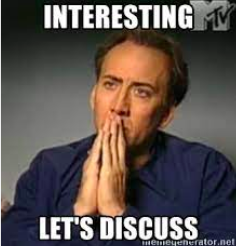






In [ ]:
# 1st convert the dates into the datetime format
df['Date']= pd.to_datetime(df["Date"])

# Now let's create separate columns
df['year'] = df.Date.dt.year
df['month'] = df.Date.dt.month
df['day'] = df.Date.dt.day
df['day_of_year'] = df.Date.dt.dayofyear

In [ ]:
df.drop(['Date'],axis=1,inplace=True)

# Data Preprocessing
Next step in preparing our data would be to make all columns have numerical values.


In [ ]:
for col_name in list(df.select_dtypes(include = "object").columns):
  print('Number of unique values in column %s is %d\n' %(col_name,len(df[col_name].unique())))

Number of unique values in column Location is 49

Number of unique values in column WindGustDir is 16

Number of unique values in column WindDir9am is 16

Number of unique values in column WindDir3pm is 16

Number of unique values in column RainToday is 2

Number of unique values in column RainTomorrow is 2



For wind directions, we'll use *multilabel* encoding, based on the directions in the data: north, east, south and west.

In [ ]:
df['WindGustDir'].value_counts()

W      18859
SE      9241
E       8985
N       8941
SSE     8905
S       8859
WSW     8802
SW      8702
SSW     8541
WNW     7960
NW      7939
ENE     7924
ESE     7244
NE      7002
NNW     6511
NNE     6372
Name: WindGustDir, dtype: int64

In [ ]:
  direction_names = ['N','E','S','W']
  def encode_wind_dirs(val):
      output = np.zeros([4])
      itr = 0
      for dirc in direction_names:
        if dirc in val:
          output[itr] = 1
        itr += 1

      return pd.Series(output)

In [ ]:
df[['WindGustDir_N','WindGustDir_E','WindGustDir_S','WindGustDir_W']] = df.apply(lambda x: encode_wind_dirs(x['WindGustDir']), axis=1)
df[['WindDir9am_N','WindDir9am_E','WindDir9am_S','WindDir9am_W']] = df.apply(lambda x: encode_wind_dirs(x['WindDir9am']), axis=1)
df[['WindDir3pm_N','WindDir3pm_E','WindDir3pm_S','WindDir3pm_W']] = df.apply(lambda x: encode_wind_dirs(x['WindDir3pm']), axis=1)

As for the Location column, let's use a categorical mapping.

Hint: in a more realistic scenario, it would be better to geo-encode the locations, so that the algorithm could benefit from the information of locations that are closeby each other.

In [ ]:
df['Location'] = df['Location'].astype('category').cat.codes

Finally, let's convert the RainToday and RainTomorrow columns to 0/1

In [ ]:
for col_name in ['RainToday','RainTomorrow']:
    df[col_name] = df[col_name].map(dict(Yes=1, No=0))
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindGustDir_S,WindGustDir_W,WindDir9am_N,WindDir9am_E,WindDir9am_S,WindDir9am_W,WindDir3pm_N,WindDir3pm_E,WindDir3pm_S,WindDir3pm_W
0,2,13.4,22.9,0.6,5.44227,7.636766,W,44.0,W,WNW,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,2,7.4,25.1,0.0,5.44227,7.636766,WNW,44.0,NNW,WSW,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,2,12.9,25.7,0.0,5.44227,7.636766,WSW,46.0,W,WSW,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,2,9.2,28.0,0.0,5.44227,7.636766,NE,24.0,SE,E,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,2,17.5,32.3,1.0,5.44227,7.636766,W,41.0,ENE,NW,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
# Let's drop non-numeric columns
df.drop(['WindGustDir','WindDir9am','WindDir3pm'], axis=1, inplace=True)

### Normalization/Stadardization
Our next step would be to "normalize" all the columns so thatthey have a "similar" range. To this end, we will use scikit-learn's SatndardScaler, to make the selected columns have the normal distribution.

In [ ]:
target_variable = df.pop('RainTomorrow')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

standard_scaling_columns = list(df.columns)
df[standard_scaling_columns] = scaler.fit_transform(df[standard_scaling_columns])
df[standard_scaling_columns].describe()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,WindGustDir_S,WindGustDir_W,WindDir9am_N,WindDir9am_E,WindDir9am_S,WindDir9am_W,WindDir3pm_N,WindDir3pm_E,WindDir3pm_S,WindDir3pm_W
count,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,...,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000
mean,0.494168,0.487925,0.529982,0.006334,0.037499,0.527412,0.263608,0.107560,0.213627,0.688753,...,0.428264,0.478127,0.478034,0.408660,0.399909,0.382869,0.393076,0.440339,0.478489,0.431233
std,0.296529,0.150853,0.134398,0.022817,0.022205,0.190133,0.101854,0.068156,0.100506,0.189835,...,0.494829,0.499523,0.499519,0.491588,0.489881,0.486089,0.488435,0.496430,0.499539,0.495250
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.229167,0.379717,0.429112,0.000000,0.026564,0.507474,0.193798,0.053846,0.149425,0.570000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.483491,0.517958,0.000000,0.037533,0.526673,0.255814,0.100000,0.218316,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.750000,0.596698,0.623819,0.002156,0.041379,0.620690,0.310078,0.146154,0.275862,0.830000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Important Note**: In practice, it is better to perform normalization *after* we have separated data into train and test, and use only the train set for deriving normalization coefficient. The reason is that we supposedly do not have access to the test data.

# Pareparing Train and Test Sets
Let's break our data into train and test sets to better evaluate the performance of our algorithm.

In [ ]:
# First, let's separate the target column, price
y = target_variable

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(df,y,test_size=0.3)
print(X_train.shape)
print(X_test.shape)

(98550, 34)
(42237, 34)


# Classification
Now it is time to test classification algorithms in action, starting from linear classifiers.

In [ ]:
# Diable warnings about max_itr not reached etc.!
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

### <font color="green"> XGBoost
First, let's set a benchmark by using XGBoost as a classifier and see what score we obtain

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=50)
model.fit(X_train, y_train,eval_metric=f1_score)
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.77


### <font color="green"> Multilayer Perceptron Using Scikit-Learn
Now that we have the benchmark F1 score, let's go for a simple network: multilayer feedforward Perceptron model (i.e. neurons are binary).

For this simple architecture, we can use Scikit-Learn's MLPClassifier classifier:

In [ ]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500)
model.fit(X_train, y_train)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), max_iter=500,
              solver='lbfgs')

In [ ]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.75


In [ ]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test, predictions, average='macro')

(0.7960363941389366, 0.7214165282389915, 0.7474167463537147, None)

Not a bad score for the first try.

Let's explore some of the parameters a bit more, starting with the number of hidden neurons, i.e. what score will we get if we add more hidden layers and with more neurons?

In [ ]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(50, 20,10),max_iter=500)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.76


How about reducing the number of hidden neurons?!

In [ ]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(5),max_iter=500)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.75


What about the effect of activation function? Does it affect the score?

In [ ]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(5,2),max_iter=500,activation='logistic')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.75


What about the regularization parameter?

In [ ]:
model = MLPClassifier(solver='lbfgs', alpha=1e-1,hidden_layer_sizes=(5, 2),max_iter=500)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions, average='macro'))

Macro F1-score is 0.75


A Confusion matrix could help us see which part we are doing better on:

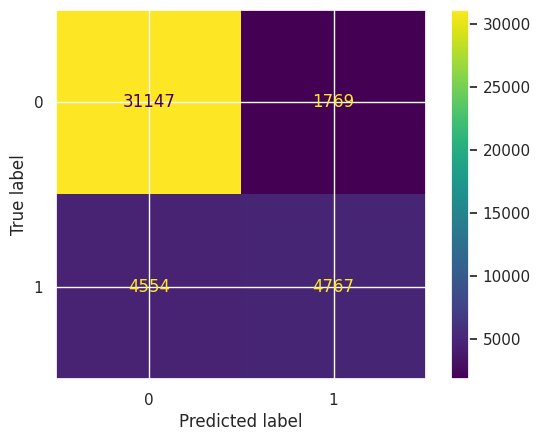

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
predictions = model.predict(X_test)
cm = confusion_matrix(y_test, predictions)#, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#display_labels=classifier.classes_)
disp.plot()

It seems that we are especially not performing well on predicting if it rains (the algorithms perform much better for predicting it will NOT rain!)

### <font color="green"> Multi-layer Feedforward Networks with Keras
Next step would be create some networks, probably with more sophisticated architectures, using other available libraries.

We start with a similar multilayer feedforward network, built with Keras.

In [ ]:
# Importing necessary libraries
from keras.models import Sequential
from keras.layers import Dense
from keras import callbacks
import tensorflow as tf

Next, let's add as many layers as we want, with different sizes:

In [ ]:
model = Sequential()

# Add a layer with 30 hidden neurons
model.add(Dense(30, input_dim=X_train.shape[1], activation='sigmoid'))

# Add a layer with 10 hidden neurons
model.add(Dense(10, activation='relu'))

# Add a layer with 2 hidden neurons
model.add(Dense(3, activation='tanh'))

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid'))

Now that we have the model, we need to *compile* it, i.e.


*   Specifying the optimization algorithm,
*   Setting the loss function,
*   Choosing an accuracy metric,
*   Set an early stopping mechanism for the situation where there seems to be no point in continuing the training



In [ ]:
#Early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,          # minimium amount of change to be considered an improvement
    patience=20,              # number of epochs to wait before deciding there is no significant improvement in training
    restore_best_weights=True,
)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr=0.01),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )

### Given the output is sigmoid, can you guess what "binary cross entropy" loss represents?
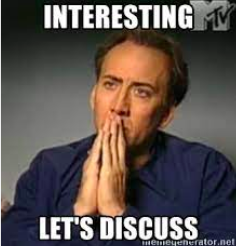






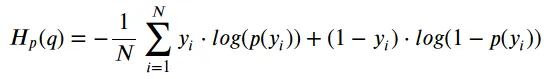

Now, let's perform the training:

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 150,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/150
4928/4928 [==============================] - 19s 3ms/step - loss: 0.3838 - precision: 0.6837 - recall: 0.4626 - val_loss: 0.3639 - val_precision: 0.7606 - val_recall: 0.4185
Epoch 2/150
4928/4928 [==============================] - 16s 3ms/step - loss: 0.3620 - precision: 0.6966 - recall: 0.5051 - val_loss: 0.3531 - val_precision: 0.6929 - val_recall: 0.5433
Epoch 3/150
4928/4928 [==============================] - 17s 4ms/step - loss: 0.3578 - precision: 0.7120 - recall: 0.5013 - val_loss: 0.3589 - val_precision: 0.7737 - val_recall: 0.4282
Epoch 4/150
4928/4928 [==============================] - 31s 6ms/step - loss: 0.3551 - precision: 0.7197 - recall: 0.4887 - val_loss: 0.3465 - val_precision: 0.7325 - val_recall: 0.4956
Epoch 5/150
4928/4928 [==============================] - 19s 4ms/step - loss: 0.3527 - precision: 0.7282 - recall: 0.4871 - val_loss: 0.3469 - val_precision: 0.7025 - val_recall: 0.5363
Epoch 6/150
4928/4928 [==============================] - 17s 3ms/step 

In [ ]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions>0.4, average='macro'))

1320/1320 [==============================] - 2s 2ms/step
Macro F1-score is 0.77


In [ ]:
hist_df.head()

,loss,precision,recall,val_loss,val_precision,val_recall
0,0.383849,0.683666,0.462642,0.363931,0.760623,0.418519
1,0.361973,0.696560,0.505125,0.353130,0.692944,0.543287
2,0.357782,0.711963,0.501253,0.358944,0.773735,0.428241
3,0.355143,0.719701,0.488667,0.346515,0.732467,0.495602
4,0.352693,0.728248,0.487130,0.346889,0.702547,0.536343


Let's see the progress of our algorithm in each iteration:

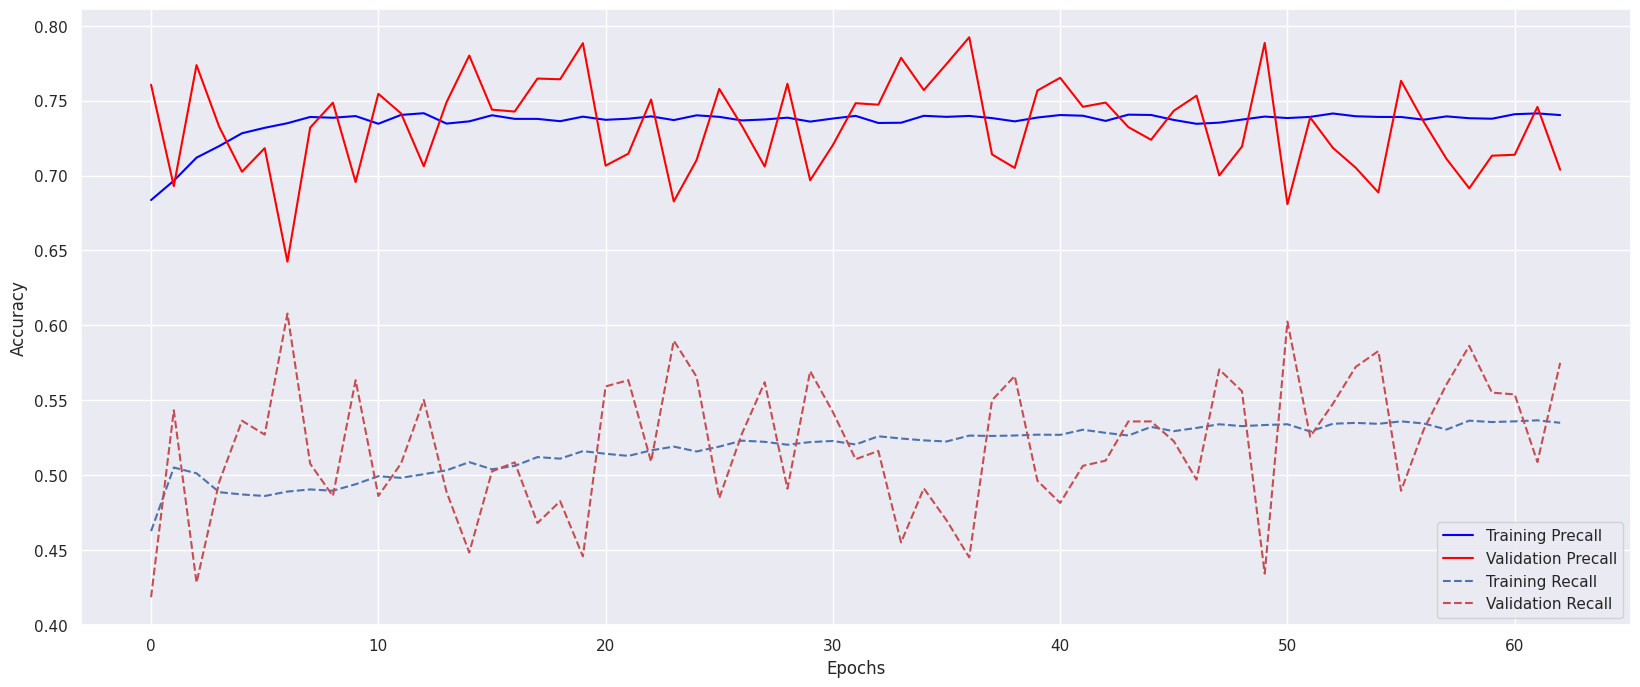

In [ ]:
hist_df = pd.DataFrame(history.history)
plt.figure(figsize=(20,8))
plt.plot(hist_df.loc[:, ['precision']], 'blue', label='Training Precall')
plt.plot(hist_df.loc[:, ['val_precision']],'red', label='Validation Precall')
plt.plot(hist_df.loc[:, ['recall']], 'b--', label='Training Recall')
plt.plot(hist_df.loc[:, ['val_recall']],'r--', label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="best")

plt.show()

#### <font color="orange">Same Architecture with PyTorch
Now that we have seen how we can use Keras to create neural networks, let's see how we can accomplish the same with PyTorch.

In [ ]:
# Importing the necessary libraries
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch import Tensor

First, we need to convert our data to a format comaptible with PyTorch:

In [ ]:
# transform to torch tensor
tensor_X_train = Tensor(X_train.values.astype(np.float32))
tensor_y_train = Tensor(y_train.values.astype(np.float32))
tensor_X_test = Tensor(X_test.values.astype(np.float32))
tensor_y_test = Tensor(y_test.values.astype(np.float32))

# create the datset
train_set = TensorDataset(tensor_X_train,tensor_y_train)
test_set = TensorDataset(tensor_X_test,tensor_y_test)


# create your dataloader
train_dl = DataLoader(train_set,batch_size=32, shuffle=True)
test_dl = DataLoader(test_set,batch_size=32, shuffle=True)


In [ ]:
layers = []
layers.append(nn.Linear(X_train.shape[1], 30))
layers.append(nn.ReLU())

layers.append(nn.Linear(30, 3))
layers.append(nn.Tanh())

layers.append(nn.Linear(3, 1))
layers.append(nn.Sigmoid())

model = nn.Sequential(*layers)

In [ ]:
# define the optimization
from torch.nn import BCELoss
from torch.optim import Adam

criterion = BCELoss()
optimizer = Adam(model.parameters(), lr=0.0001)

Now let's perform the training.

In contrast to Keras, we need to create our own training loop, which is a bit cumbersome!

In [ ]:
# loop over the dataset multiple times
for epoch in range(100):

    running_loss = 0.0
    for i, (inputs, targets) in enumerate(train_dl):

        # clear the gradients
        optimizer.zero_grad()
        # compute the model output
        yhat = model(inputs)
        # calculate loss
        loss = criterion(yhat.ravel(), targets)

        # credit assignment
        loss.backward()
        # update model weights
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if not i % 5000:    # print every 2000 mini-batches
            print('[%d, %5d] F1 Score is: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

[1,     1] F1 Score is: 0.000
[2,     1] F1 Score is: 0.000
[3,     1] F1 Score is: 0.000
[4,     1] F1 Score is: 0.000
[5,     1] F1 Score is: 0.000
[6,     1] F1 Score is: 0.000
[7,     1] F1 Score is: 0.000
[8,     1] F1 Score is: 0.000
[9,     1] F1 Score is: 0.000
[10,     1] F1 Score is: 0.000
[11,     1] F1 Score is: 0.000
[12,     1] F1 Score is: 0.000
[13,     1] F1 Score is: 0.000
[14,     1] F1 Score is: 0.000
[15,     1] F1 Score is: 0.000
[16,     1] F1 Score is: 0.000
[17,     1] F1 Score is: 0.000
[18,     1] F1 Score is: 0.000
[19,     1] F1 Score is: 0.000
[20,     1] F1 Score is: 0.000
[21,     1] F1 Score is: 0.000
[22,     1] F1 Score is: 0.000
[23,     1] F1 Score is: 0.000
[24,     1] F1 Score is: 0.000
[25,     1] F1 Score is: 0.000
[26,     1] F1 Score is: 0.000
[27,     1] F1 Score is: 0.000
[28,     1] F1 Score is: 0.000
[29,     1] F1 Score is: 0.000
[30,     1] F1 Score is: 0.000
[31,     1] F1 Score is: 0.000
[32,     1] F1 Score is: 0.000
[33,     1] F1 Sc

Finally, it is time to evaluate our model. We have to this part manually as well.

In [ ]:
precision = 0
recall = 0
total_itr = 0
for i, (inputs, targets) in enumerate(test_dl):
    # evaluate the model on the test set
    yhat = model(inputs).ravel()
    pr,rc,f1,_ = precision_recall_fscore_support(yhat.detach().numpy()>0.4, targets.detach().numpy(), average='macro')
    precision += pr
    recall += rc
    total_itr += 1

precision /= total_itr
recall /= total_itr

print('Macro F1-score is %.2f' %(2*precision*recall/(precision+recall)))

Macro F1-score is 0.77


The final result looks very competetitive with what we have achieved so far.


PyTorch ha its adavntages and strengths. But given the effort it takes to create, train and test models, we proceed with only Keras for the rest of the session.

### <font color="green">Simple Feedforward Colvultional Networks (with Keras)</font>
Convolutional neural networks are especially useful in image processing, where a convultional filter is "moved" around the image to extract features.

We will learn more about convolutional neural networks in later sessions. But creating a simple example is very straightforward.

In [ ]:
from keras.layers import Conv1D, Input, Flatten
model = Sequential()

# Add a layer with 20 hidden neurons
#model.add(Dense(50, input_shape=(None,X_train.shape[1]), activation='relu'))

# Add the convolutional layer
model.add(Conv1D(filters=10, kernel_size=3, activation='relu',input_shape=(X_train.shape[1],1)))

# Add a layer with 2 hidden neurons
model.add(Dense(3, activation='tanh'))

model.add(Flatten())

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr=0.001),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )

Once we have the model, we can briefly take a look at the layers, their type and their shape to get a better overall view of the whole network structure:

In [ ]:
model.summary()

Now let's train our network:

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 150,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/150
4928/4928 [==============================] - 19s 3ms/step - loss: 0.3832 - precision_1: 0.6964 - recall_1: 0.4197 - val_loss: 0.3621 - val_precision_1: 0.6668 - val_recall_1: 0.5498
Epoch 2/150
4928/4928 [==============================] - 17s 3ms/step - loss: 0.3604 - precision_1: 0.7088 - recall_1: 0.4928 - val_loss: 0.3568 - val_precision_1: 0.7492 - val_recall_1: 0.4308
Epoch 3/150
4928/4928 [==============================] - 17s 3ms/step - loss: 0.3579 - precision_1: 0.7119 - recall_1: 0.4966 - val_loss: 0.3550 - val_precision_1: 0.6917 - val_recall_1: 0.5333
Epoch 4/150
4928/4928 [==============================] - 17s 3ms/step - loss: 0.3563 - precision_1: 0.7112 - recall_1: 0.4994 - val_loss: 0.3529 - val_precision_1: 0.7231 - val_recall_1: 0.4824
Epoch 5/150
4928/4928 [==============================] - 18s 4ms/step - loss: 0.3554 - precision_1: 0.7147 - recall_1: 0.5002 - val_loss: 0.3517 - val_precision_1: 0.7335 - val_recall_1: 0.4752
Epoch 6/150
4928/4928 [=======

In [ ]:
hist_df = pd.DataFrame(history.history)

In [ ]:
hist_df.columns

Index(['loss', 'precision_4', 'recall_4', 'val_loss', 'val_precision_4',
       'val_recall_4'],
      dtype='object')

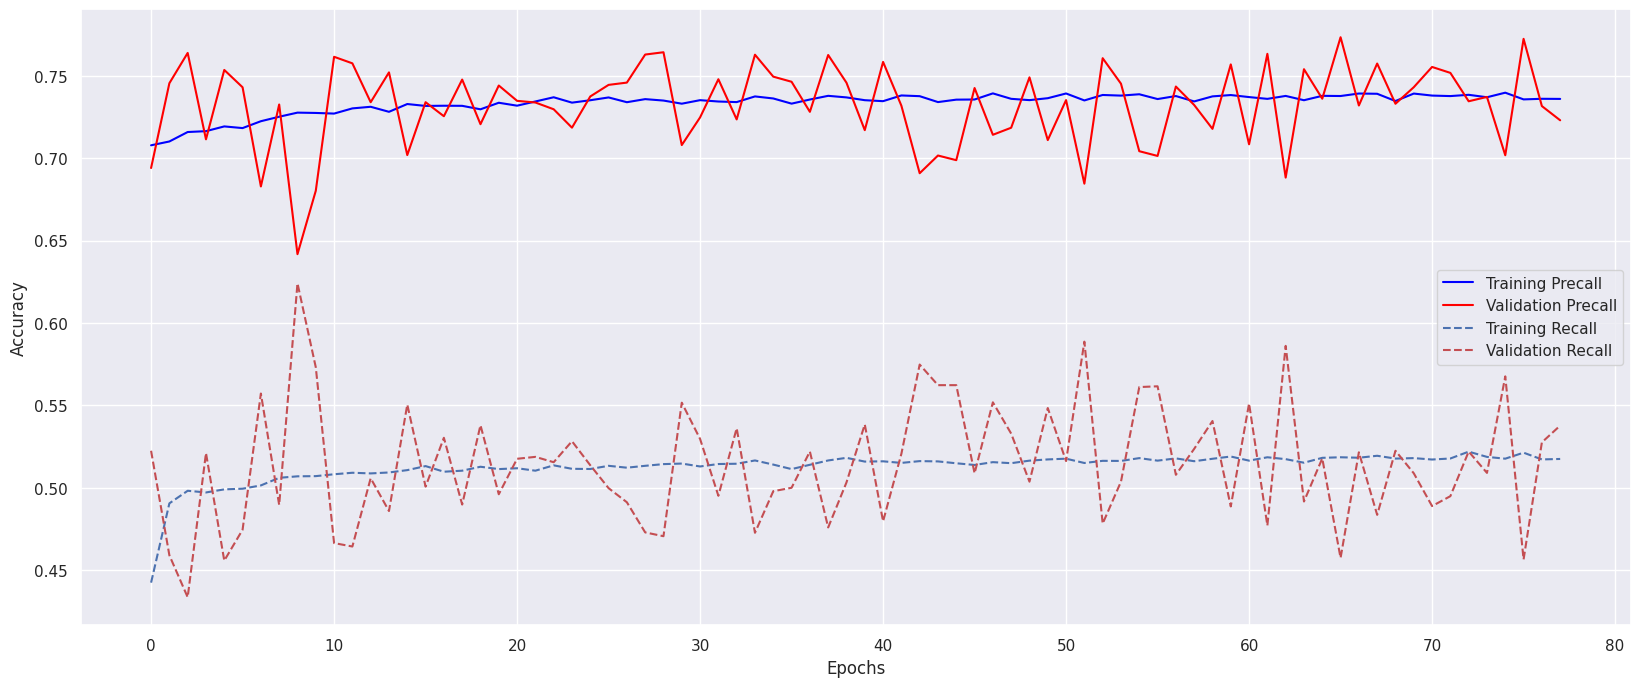

In [ ]:
hist_df = pd.DataFrame(history.history)
plt.figure(figsize=(20,8))
plt.plot(hist_df.loc[:, ['precision_4']], 'blue', label='Training Precall')
plt.plot(hist_df.loc[:, ['val_precision_4']],'red', label='Validation Precall')
plt.plot(hist_df.loc[:, ['recall_4']], 'b--', label='Training Recall')
plt.plot(hist_df.loc[:, ['val_recall_4']],'r--', label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="best")

plt.show()

In [ ]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions>0.4, average='macro'))

### <font color="green">Feedforward Layers with Internally Connected Layers (with Keras)
In convolutional neural networks, the weights in the filters are shared (i.e. we train one set of filter weights and the weights are used in different strides).

But we can remove this constraint and create an architecture where the weights of each filter is learned as well.

In [ ]:
from keras.layers import LocallyConnected1D
model = Sequential()

# Add a layer with 20 hidden neurons
#model.add(Dense(50, input_shape=(None,X_train.shape[1]), activation='relu'))

# Add the convolutional layer
model.add(LocallyConnected1D(20,kernel_size=3, activation='relu',input_shape=(X_train.shape[1],1)))

# Add a layer with 2 hidden neurons
model.add(Dense(3, activation='tanh'))

model.add(Flatten())

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr=0.001),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 locally_connected1d (Local  (None, 32, 20)            2560      
 lyConnected1D)                                                  
                                                                 
 dense_12 (Dense)            (None, 32, 3)             63        
                                                                 
 flatten_1 (Flatten)         (None, 96)                0         
                                                                 
 dense_13 (Dense)            (None, 1)                 97        
                                                                 
Total params: 2720 (10.62 KB)
Trainable params: 2720 (10.62 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### visualizing the network
In addition to viewing the summary of the model, we can visualize the structure as well!

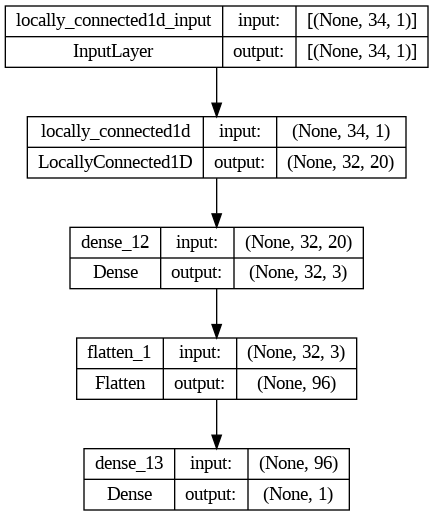

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True)

Pretty neat :)

Now let's train our model:

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 150,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/150
4928/4928 [==============================] - 43s 8ms/step - loss: 0.3750 - precision_4: 0.7078 - recall_4: 0.4424 - val_loss: 0.3554 - val_precision_4: 0.6940 - val_recall_4: 0.5225
Epoch 2/150
4928/4928 [==============================] - 20s 4ms/step - loss: 0.3596 - precision_4: 0.7101 - recall_4: 0.4905 - val_loss: 0.3538 - val_precision_4: 0.7455 - val_recall_4: 0.4590
Epoch 3/150
4928/4928 [==============================] - 20s 4ms/step - loss: 0.3576 - precision_4: 0.7159 - recall_4: 0.4982 - val_loss: 0.3545 - val_precision_4: 0.7639 - val_recall_4: 0.4336
Epoch 4/150
4928/4928 [==============================] - 23s 5ms/step - loss: 0.3557 - precision_4: 0.7164 - recall_4: 0.4972 - val_loss: 0.3501 - val_precision_4: 0.7114 - val_recall_4: 0.5211
Epoch 5/150
4928/4928 [==============================] - 20s 4ms/step - loss: 0.3551 - precision_4: 0.7193 - recall_4: 0.4990 - val_loss: 0.3503 - val_precision_4: 0.7535 - val_recall_4: 0.4558
Epoch 6/150
4928/4928 [=======

In [ ]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions>0.4, average='macro'))

1320/1320 [==============================] - 4s 3ms/step
Macro F1-score is 0.77


### <font color="green"> Recurrent Neural Networks (RNN) with Keras </font>
Upto now, most of the structures we have seen were feedforward. It is now time to see some recurrent strcutures. Luckily, Keras has some options ready for us to use.

Before doing so, we need to create a "time-series" dataset.

Here's the logic: the probability of raining tomorrow not only depends on the weather today, but probably on the weather in the past few days. So to predict the weather (rain) for each day, we need to have a matrix of the weather (features) for the past few days, i.e. instead of predicting the tomorrow's weather from a vector of today features, we will use a matrix of past few days features.


In [ ]:
X_train.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,WindGustDir_S,WindGustDir_W,WindDir9am_N,WindDir9am_E,WindDir9am_S,WindDir9am_W,WindDir3pm_N,WindDir3pm_E,WindDir3pm_S,WindDir3pm_W
113674,0.958333,0.518868,0.449905,0.001617,0.037533,0.526673,0.255814,0.153846,0.218391,0.55,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
17861,0.500000,0.412736,0.468809,0.000000,0.037533,0.526673,0.264055,0.000000,0.122004,0.82,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
57788,0.104167,0.375000,0.270321,0.009164,0.037533,0.526673,0.240310,0.169231,0.252874,1.00,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
77781,0.687500,0.495283,0.415879,0.000000,0.023619,0.448418,0.193798,0.115385,0.149425,0.75,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
107161,1.000000,0.360849,0.553875,0.000000,0.063448,0.623995,0.573643,0.284615,0.505747,0.32,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


**Note**: probably a more accurate thing to do is to perform the above operation for *each location*, i.e. the weather tomorrow depends on the weather in the past few days for that particular location. But since our goal here is to practice using Keras's features, we perform this step only for a particular location. We can repeat this for other locations later.

In [ ]:
inds = X_train[X_train['Location']==0.125000].index
X_train_loc = X_train.loc[inds]
y_train_loc = y_train.loc[inds]

In [ ]:
inds = X_test[X_test['Location']==0.125000].index
X_test_loc = X_test.loc[inds]
y_test_loc = y_test.loc[inds]
print(y_test_loc.shape)

(910,)


Now to accomplish our goal in generating the proper dataset, we can use one of Keras's helper functions, to transform our data into the proper format:

In [ ]:
ds_train = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=X_train_loc,
            targets=y_train_loc,
            sequence_length=7,     # Include past week's weather
            sequence_stride=1,
            shuffle=True,
            batch_size=16,)

In [ ]:
for batch in ds_train.take(1):
    inputs, targets = batch

print(inputs.shape)
print(targets.shape)

(16, 7, 34)
(16,)


We will use "SimpleRNN layer", which is a "fully-connected RNN where the output is to be fed back to input".


In [ ]:
from keras.layers import SimpleRNN, LSTMCell
model = Sequential()

# Add the recurrent
model.add(SimpleRNN(30, input_shape=(inputs.shape[1], inputs.shape[2]), activation='relu'))

# Add a layer with 2 hidden neurons
model.add(Dense(10, activation='tanh'))

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid',input_shape=(None,20)))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr=0.001),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 30)                1950      
                                                                 
 dense_14 (Dense)            (None, 10)                310       
                                                                 
 dense_15 (Dense)            (None, 1)                 11        
                                                                 
Total params: 2271 (8.87 KB)
Trainable params: 2271 (8.87 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


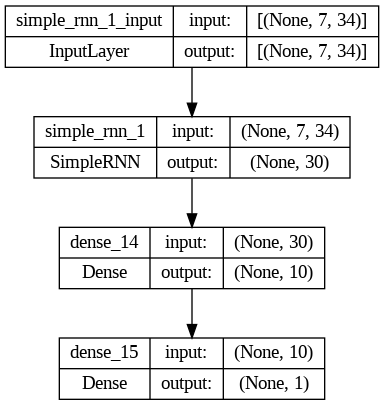

In [ ]:
plot_model(model,show_shapes=True)

In [ ]:
history = model.fit(ds_train,
                    batch_size = 16,
                    epochs = 150,
                    #validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/150
132/133 [============================>.] - ETA: 0s - loss: 0.4867 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00

133/133 [==============================] - 4s 10ms/step - loss: 0.4871 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00
Epoch 2/150
128/133 [===========================>..] - ETA: 0s - loss: 0.4766 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00

133/133 [==============================] - 2s 14ms/step - loss: 0.4767 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00
Epoch 3/150
132/133 [============================>.] - ETA: 0s - loss: 0.4686 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00

133/133 [==============================] - 1s 8ms/step - loss: 0.4684 - precision_7: 0.0000e+00 - recall_7: 0.0000e+00
Epoch 4/150
131/133 [============================>.] - ETA: 0s - loss: 0.4212 - precision_7: 0.5526 - recall_7: 0.0545

133/133 [==============================] - 1s 9ms/step - loss: 0.4208 - precision_7: 0.5526 - recall_7: 0.0541
Epoch 5/150
127/133 [===========================>..] - ETA: 0s - loss: 0.3707 - precision_7: 0.5567 - recall_7: 0.3021

...

133/133 [==============================] - 1s 6ms/step - loss: 0.0069 - precision_7: 1.0000 - recall_7: 0.9923
Epoch 147/150
124/133 [==========================>...] - ETA: 0s - loss: 0.0071 - precision_7: 1.0000 - recall_7: 0.9918

133/133 [==============================] - 1s 6ms/step - loss: 0.0067 - precision_7: 1.0000 - recall_7: 0.9923
Epoch 148/150
131/133 [============================>.] - ETA: 0s - loss: 0.0067 - precision_7: 1.0000 - recall_7: 0.9922

133/133 [==============================] - 1s 6ms/step - loss: 0.0066 - precision_7: 1.0000 - recall_7: 0.9923
Epoch 149/150
130/133 [============================>.] - ETA: 0s - loss: 0.0067 - precision_7: 1.0000 - recall_7: 0.9921

133/133 [==============================] - 1s 6ms/step - loss: 0.0066 - precision_7: 1.0000 - recall_7: 0.9923
Epoch 150/150
127/133 [===========================>..] - ETA: 0s - loss: 0.0066 - precision_7: 1.0000 - recall_7: 0.9919

133/133 [==============================] - 1s 9ms/step - loss: 0.0064 - precision_7: 1.0000 - recall_7: 0.9923


In [ ]:
ds_test = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=X_test_loc,
            targets=y_test_loc,
            sequence_length=7,     # Include past week's weather
            sequence_stride=1,
            shuffle=True,
            batch_size=256)

In [ ]:
f1 = 0
itr = 0
for batch in ds_test:
    test_set, targets = batch
    predictions = model.predict(test_set)
    f1 += f1_score(targets, predictions>0.25, average='macro')
    itr += 1


5/5 [==============================] - 0s 4ms/step


In [ ]:
print('Macro F1-score is %.2f' %(f1/itr))

Macro F1-score is 0.71


### <font color="green"> **Non-sequentail** Models with Keras </font>
So far, the architecures we have seen were sequential, in the sense that one layer was added on top of another layer and so on.

However, in certain cases, we might be interested to design more complex architectures. For instance, we want direct connections from layer 2 to layer 5 of the network (instead of moving from layer 2 to 3 and from layer 3 to 4 to layer 5). This and similar ideas can be accomplished using *non-sequential* models in Keras.

In [ ]:
from keras.layers import Add, Concatenate
from keras.models import Model

input_layer = Input(shape=(X_train.shape[1],))

# Pass the output of the input layer into a hidden layer
hidden_layer_1 = Dense(20,activation='relu')(input_layer)

# The second hidden layer receives input from the input_layer and not the last hidden layer
hidden_layer_2 = Dense(10,activation='tanh')(input_layer)

# The second hidden layer receives input from the input_layer and not the last hidden layer
hidden_layer_3 = Dense(10,activation='tanh')(hidden_layer_1)


#added = tf.keras.layers.Add()([hidden_layer_1, hidden_layer_2])
#add_layer = Add()([hidden_layer_2,hidden_layer_1])

add_layer = Concatenate()([hidden_layer_3, hidden_layer_2])

output_layer = Dense(1,activation='sigmoid')(add_layer)

# Defined an actual model out of the above with an output being the same shape as the above layer and input being the size as the input layer
model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr=0.001),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 34)]                 0         []                            
                                                                                                  
 dense_16 (Dense)            (None, 20)                   700       ['input_2[0][0]']             
                                                                                                  
 dense_18 (Dense)            (None, 10)                   210       ['dense_16[0][0]']            
                                                                                                  
 dense_17 (Dense)            (None, 10)                   350       ['input_2[0][0]']             
                                                                                            

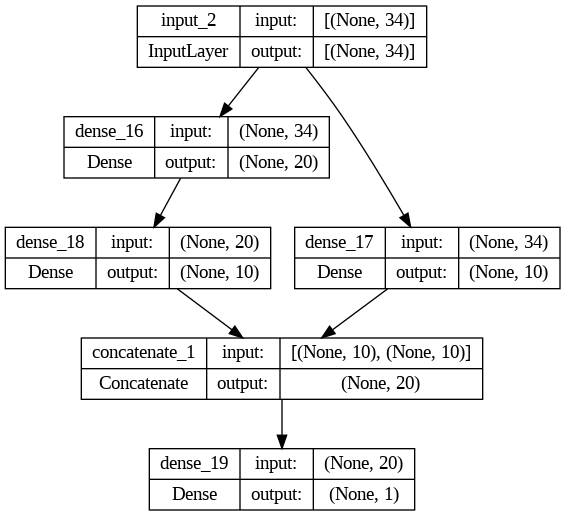

In [ ]:
plot_model(model,show_shapes=True)

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 150,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/150
4928/4928 [==============================] - 21s 4ms/step - loss: 0.3811 - precision_8: 0.6937 - recall_8: 0.4403 - val_loss: 0.3605 - val_precision_8: 0.7627 - val_recall_8: 0.4278
Epoch 2/150
4928/4928 [==============================] - 18s 4ms/step - loss: 0.3596 - precision_8: 0.7031 - recall_8: 0.5023 - val_loss: 0.3604 - val_precision_8: 0.7684 - val_recall_8: 0.4262
Epoch 3/150
4928/4928 [==============================] - 19s 4ms/step - loss: 0.3564 - precision_8: 0.7071 - recall_8: 0.5097 - val_loss: 0.3481 - val_precision_8: 0.7122 - val_recall_8: 0.5229
Epoch 4/150
4928/4928 [==============================] - 18s 4ms/step - loss: 0.3540 - precision_8: 0.7070 - recall_8: 0.5122 - val_loss: 0.3568 - val_precision_8: 0.7739 - val_recall_8: 0.4255
Epoch 5/150
4928/4928 [==============================] - 18s 4ms/step - loss: 0.3520 - precision_8: 0.7123 - recall_8: 0.5187 - val_loss: 0.3449 - val_precision_8: 0.7283 - val_recall_8: 0.5139
Epoch 6/150
4928/4928 [=======

In [ ]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions>0.4, average='macro'))

1320/1320 [==============================] - 2s 2ms/step
Macro F1-score is 0.77


Not bad! we got an improvement in the results!

# TF, Keras Limitations: Custom architecture
As seen from the previous examples, Keras is excellent when designing rather standard and popoular network architectures (e.g. feedforward, convolutional neural networks and RNN). However, if we fancy a particular architecture, or specific layer type (e.g. one with feedback loops, or particular connections from one layer to another), things will get complicated.


In some cases, we might be able to use off-the-shelf modules, such as the ones we used to esign *non-sequential* network models. However, in some other cases, even these modules won't be of help and we need to create our own custom structure. The following links provide some clues on how to commplish that:


*   [Making new layers in Keras](https://keras.io/guides/making_new_layers_and_models_via_subclassing/)
*   [Custom Layers in TensorFlow](https://www.tensorflow.org/tutorials/customization/custom_layers)
*   [Custom neural networks in Keras: a street fighter’s guide to build a graphCNN](https://towardsdatascience.com/custom-neural-networks-in-keras-a-street-fighters-guide-to-build-a-graphcnn-e91f6b05f12e?gi=4b189853e82b)
*    [Recursive Links in Keras](https://github.com/keras-team/keras/issues/5160)


If none of the above approaches worked, it would be the time to write your own custom model purely in Python. It is a fun and constructive experience!




Any Final Thoughts?

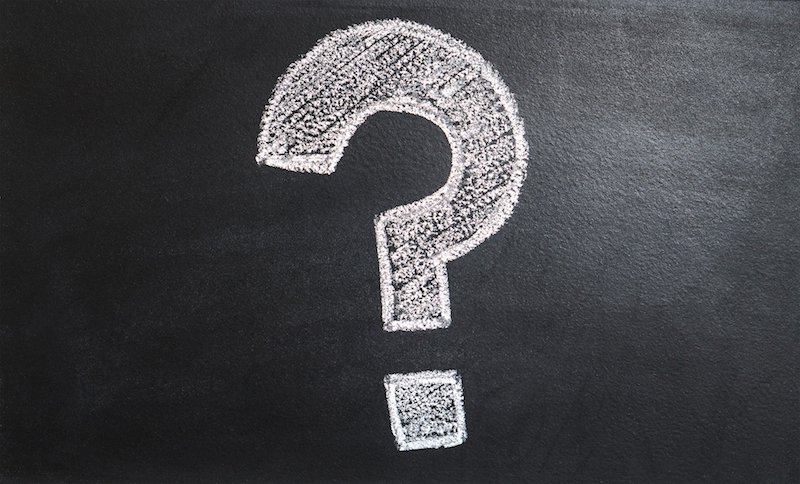

# Don't Forget the Survey!
Please help us improve the quality of the lab sessions by filling this [short suvery](https://forms.gle/yX3CQPfJo6pJMQh88) about today's session.


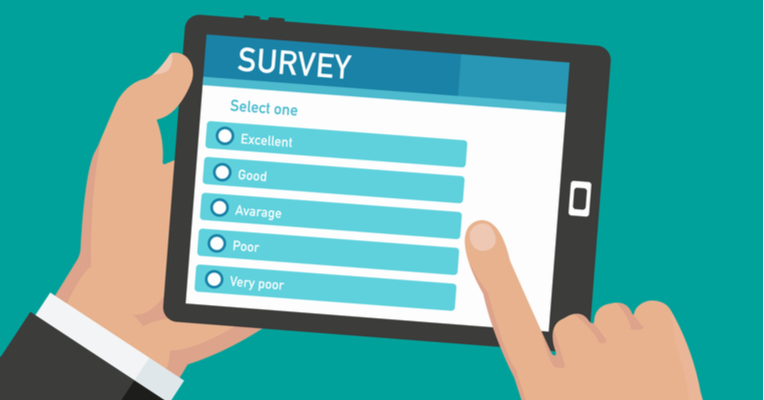